In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
protein_localization = np.load( path + 'protein_localization_dataset.npz')

In [3]:
investigate_dataset(protein_localization)

['X', 'y', 'genes']

Array shapes:
X shape: (9769, 12288, 6)
y shape: (9769, 12)
genes shape: (9769,)

First few y values: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 0. 1. 0. 0.]


In [4]:
pca_embeddings, pca_model = isoform_to_gene_embeddings_pca(protein_localization['X'], protein_localization['genes'], n_components=2048)
print(f"PCA embeddings shape: {pca_embeddings.shape}")

PCA embeddings shape: (9769, 2048)


In [5]:
total_explained_variance = np.sum(pca_model.explained_variance_ratio_)
print(f"Total explained variance by PCA {total_explained_variance:.2%}")

Total explained variance by PCA 65.05%


In [6]:
pca_embeddings = create_gene_embedding_dataframe(pca_embeddings, protein_localization['genes'])
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856910,-3.787095,17.809717,9.046454,-4.546179,1.066543,-10.573643,-3.584061,-7.779910,4.624028,...,0.040558,-0.115715,-0.660479,-1.647286,0.059439,0.799480,-0.169579,-0.488120,0.388410,-0.475349
FGR,-10.732220,16.028664,-5.620770,-0.390511,0.571052,-7.165587,-3.193249,0.394350,5.179990,1.700157,...,0.314322,-0.391261,-0.126518,0.217455,-0.069404,0.595413,0.133012,-0.114623,0.006850,-1.184946
CFH,7.006851,23.785358,-7.231877,9.518290,5.971951,5.527488,2.496065,-2.941044,-10.176363,6.325662,...,-1.302801,-0.480172,0.706650,0.625798,-0.440601,1.119538,1.450707,0.577081,0.953788,-0.440821
GCLC,3.741444,16.818729,-5.728347,10.611611,1.751369,1.134253,0.392474,2.120256,-4.206463,-1.344753,...,-0.962274,-1.577304,-0.429222,0.226423,0.530666,-0.174774,0.099094,0.252054,-0.197669,-0.214128
NFYA,16.261385,-2.448980,11.577347,-1.681709,-6.334064,6.198145,9.163068,2.846436,6.783427,-1.467580,...,-1.073260,-1.410348,0.047294,-0.999184,-0.173432,-0.002035,0.585042,1.256920,-0.811149,-1.959124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164516,-0.711315,3.695392,-9.967208,-3.282068,2.942989,5.236727,-5.229366,-4.926521,-3.050560,...,0.497897,-0.055834,0.293079,-0.127654,-0.083947,0.065423,0.077688,-0.165643,-0.175936,-0.008042
H2AC19,-16.295761,-2.631285,-1.827587,-9.977594,-2.927907,5.729970,-1.169987,-5.805991,-4.658194,-2.984223,...,0.046101,0.364238,-0.199048,0.120014,0.065425,0.033066,0.056762,-0.051506,-0.174983,-0.078441
ENSG00000289346,9.783043,15.400048,-5.534088,8.447061,9.952056,11.425193,5.756490,-8.421690,-7.163852,1.605443,...,-0.057904,-0.813152,-0.055532,0.788912,0.005638,0.189382,-0.736546,0.102384,-0.525659,-0.854974


In [7]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [8]:
pca_embeddings

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856910,-3.787095,17.809717,9.046454,-4.546179,1.066543,-10.573643,-3.584061,-7.779910,4.624028,...,0.040558,-0.115715,-0.660479,-1.647286,0.059439,0.799480,-0.169579,-0.488120,0.388410,-0.475349
FGR,-10.732220,16.028664,-5.620770,-0.390511,0.571052,-7.165587,-3.193249,0.394350,5.179990,1.700157,...,0.314322,-0.391261,-0.126518,0.217455,-0.069404,0.595413,0.133012,-0.114623,0.006850,-1.184946
CFH,7.006851,23.785358,-7.231877,9.518290,5.971951,5.527488,2.496065,-2.941044,-10.176363,6.325662,...,-1.302801,-0.480172,0.706650,0.625798,-0.440601,1.119538,1.450707,0.577081,0.953788,-0.440821
GCLC,3.741444,16.818729,-5.728347,10.611611,1.751369,1.134253,0.392474,2.120256,-4.206463,-1.344753,...,-0.962274,-1.577304,-0.429222,0.226423,0.530666,-0.174774,0.099094,0.252054,-0.197669,-0.214128
NFYA,16.261385,-2.448980,11.577347,-1.681709,-6.334064,6.198145,9.163068,2.846436,6.783427,-1.467580,...,-1.073260,-1.410348,0.047294,-0.999184,-0.173432,-0.002035,0.585042,1.256920,-0.811149,-1.959124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164516,-0.711315,3.695392,-9.967208,-3.282068,2.942989,5.236727,-5.229366,-4.926521,-3.050560,...,0.497897,-0.055834,0.293079,-0.127654,-0.083947,0.065423,0.077688,-0.165643,-0.175936,-0.008042
H2AC19,-16.295761,-2.631285,-1.827587,-9.977594,-2.927907,5.729970,-1.169987,-5.805991,-4.658194,-2.984223,...,0.046101,0.364238,-0.199048,0.120014,0.065425,0.033066,0.056762,-0.051506,-0.174983,-0.078441
ENSG00000289346,9.783043,15.400048,-5.534088,8.447061,9.952056,11.425193,5.756490,-8.421690,-7.163852,1.605443,...,-0.057904,-0.813152,-0.055532,0.788912,0.005638,0.189382,-0.736546,0.102384,-0.525659,-0.854974


In [9]:
NCG_Known_Genes = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(NCG_Known_Genes, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
FGR,-10.732220,16.028664,-5.620770,-0.390511,0.571052,-7.165587,-3.193249,0.394350,5.179990,1.700157,...,-0.069404,0.595413,0.133012,-0.114623,0.006850,-1.184946,False,False,False,False
CFH,7.006851,23.785358,-7.231877,9.518290,5.971951,5.527488,2.496065,-2.941044,-10.176363,6.325662,...,-0.440601,1.119538,1.450707,0.577081,0.953788,-0.440821,False,False,False,False
GCLC,3.741444,16.818729,-5.728347,10.611611,1.751369,1.134253,0.392474,2.120256,-4.206463,-1.344753,...,0.530666,-0.174774,0.099094,0.252054,-0.197669,-0.214128,False,False,False,False
NFYA,16.261385,-2.448980,11.577347,-1.681709,-6.334064,6.198145,9.163068,2.846436,6.783427,-1.467580,...,-0.173432,-0.002035,0.585042,1.256920,-0.811149,-1.959124,False,False,False,False
NIPAL3,12.457926,12.927110,-4.907854,4.092935,-9.950675,0.878757,-0.440939,-0.215906,5.599688,-2.671742,...,1.264880,1.322987,-0.224388,-0.283415,0.154163,0.043520,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACACA,30.513550,-20.623848,-19.248316,-18.139883,2.916749,-19.266245,9.513418,3.320140,-7.482756,1.156810,...,0.214597,-0.109778,-0.146787,-0.635425,-0.142670,-0.190010,False,False,False,False
MRM1,-12.605596,11.342219,-3.682078,-3.019353,-2.138777,-6.591255,-3.053552,-0.243758,4.935580,-0.558456,...,-0.183689,-0.203435,0.099268,0.327980,0.156452,-0.055959,False,False,False,False
MRPL45,-14.170593,-2.043047,9.330485,-6.103011,0.369912,1.470315,8.085228,-0.145336,-0.400865,1.473329,...,0.054679,-0.488254,0.069030,-0.466170,0.123928,0.344606,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [10]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    6815
True      419
Name: count, dtype: int64

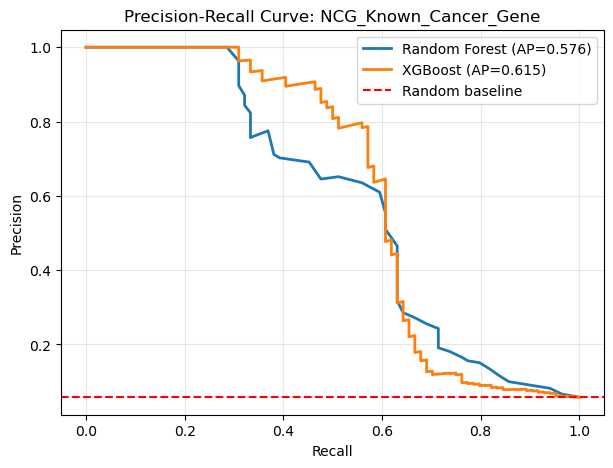

Random Forest - auPRC: 0.576
XGBoost - auPRC: 0.615



In [11]:
predict_and_plot_pr_curve(merged, 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [12]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    6580
True      654
Name: count, dtype: int64

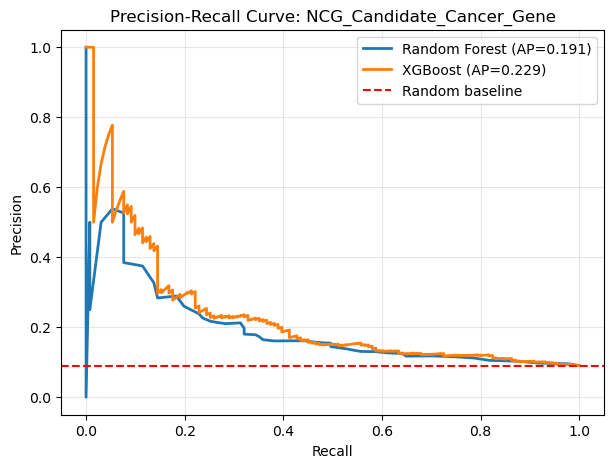

Random Forest - auPRC: 0.191
XGBoost - auPRC: 0.229



In [13]:
predict_and_plot_pr_curve(merged, 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [14]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    6901
True      333
Name: count, dtype: int64

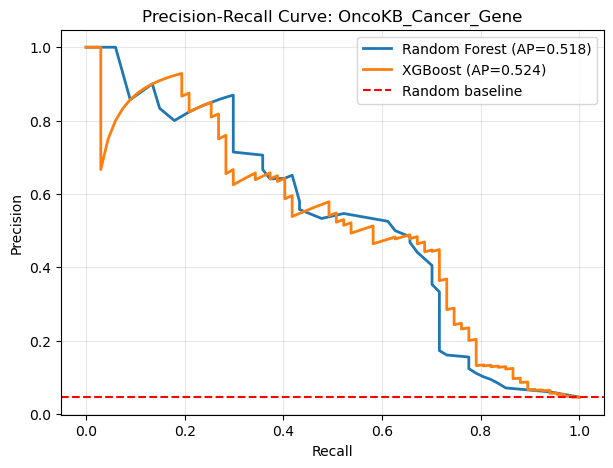

Random Forest - auPRC: 0.518
XGBoost - auPRC: 0.524



In [15]:
predict_and_plot_pr_curve(merged, 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [16]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    7067
True      167
Name: count, dtype: int64

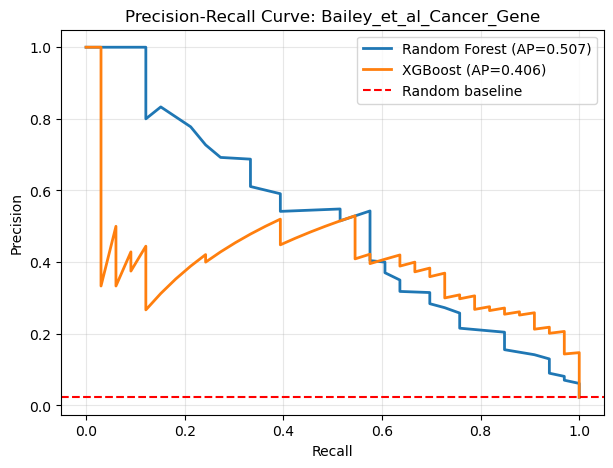

Random Forest - auPRC: 0.507
XGBoost - auPRC: 0.406



In [17]:
predict_and_plot_pr_curve(merged, 'Bailey_et_al_Cancer_Gene')